# Relatório Final: Detecção e Quantificação de Doenças em Folhas

Este notebook consolida os resultados do projeto de visão computacional voltado para a detecção automática e quantificação de severidade de doenças em folhas de batata e tomate, utilizando técnicas clássicas de processamento de imagem.

## 1. Metodologia (F6.1)

O pipeline foi construído de forma modular, permitindo a validação individual de cada etapa. A implementação baseia-se exclusivamente em bibliotecas de processamento de imagem (OpenCV) e manipulação de matrizes (NumPy).

### 1.1 Dataset e Preparação
O dataset utilizado está organizado em subpastas dentro de `SELECTED_DATA_DIR`, divididas por espécie e estado de saúde (ex: `potato_healthy`, `tomato_late_blight`). As imagens foram capturadas em ambiente controlado com fundo neutro.

### 1.2 Pré-processamento (`stage1_preproc.py`)
Para reduzir o ruído de alta frequência e garantir a consistência dimensional:
- **`gaussian_blur`**: Aplicação de filtro gaussiano (kernel 5x5) para suavização.
- **`resize_to_size`**: Redimensionamento padrão para 256x256 pixels, otimizando a velocidade de processamento sem perda significativa de detalhes diagnósticos.
- **`bgr_to_hsv` (`color.py`)**: Conversão do espaço BGR para HSV, facilitando a segmentação por cor (matiz).

### 1.3 Segmentação da Folha (`stage2_leaf_seg.py`)
A separação da folha do fundo é crítica para o cálculo da severidade:
- **`segment_leaf_otsu`**: Utiliza a limiarização global de Otsu no canal de luminância ou saturação para separar o objeto do fundo.
- **`extract_largest_contour`**: Filtra apenas o maior contorno detectado, eliminando pequenos artefatos ou ruídos de fundo.
- **`apply_mask`**: Aplica a máscara binária final à imagem original para isolar a região de interesse.

### 1.4 Detecção de Lesões (`stage3_lesion.py`)
Identificação de necrose e clorose através de faixas de cores específicas:
- **`segment_lesions_hsv`**: Define ranges para amarelos (H 15-35) e marrons. 
  - **Nota Técnica**: Como o canal H no OpenCV é circular (0-179), os tons marrons/avermelhados exigem dois intervalos (`0-15` e `160-179`) para serem capturados integralmente.
- **`intersect_with_leaf`**: Garante que apenas pixels detectados dentro da máscara da folha sejam considerados, eliminando falsos positivos externos.
- **`refine_lesion_mask`**: Aplica operações morfológicas (abertura/fechamento) para consolidar as manchas detectadas.
- **`find_lesion_contours`** e **`detect_lesions`**: Extrai os contornos individuais das lesões para visualização e análise.

### 1.5 Análise Quantitativa e Severidade (`stage4_analysis.py`)
- **`count_mask_pixels`**: Contagem de pixels brancos nas máscaras de folha e lesão.
- **`calculate_affected_percentage`**: Razão entre a área da lesão e a área total da folha.
- **`classify_severity`**: Classificação em 4 níveis:
  - **Saudável**: < 5% afetado
  - **Leve**: 5% a < 20%
  - **Moderada**: 20% a < 50%
  - **Grave**: >= 50%
- **`calculate_h_histogram`**: Gera o perfil de cores da região afetada para análise espectral.

### 1.6 Integração e Validação (`pipeline.py` & `stage5_validation.py`)
- **`process_image`**: Função principal que orquestra todo o fluxo acima para uma única imagem.
- **`process_batch`**: Execução em lote para avaliação de performance e acurácia.
- **`analyze_failures`**: Identificação automática de falsos positivos e negativos.
- **`export_results_csv`**: Persistência dos dados em `results/csv_results.csv`.

---


In [4]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import numpy as np

# Ajuste de path para importar os módulos do projeto
sys.path.insert(0, str(Path.cwd().parent))

from plant_disease.config import SELECTED_DATA_DIR, RESULTS_DIR
from plant_disease.pipeline import process_image, PipelineConfig

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 10]

print("✓ Ambiente configurado e módulos importados")


✓ Ambiente configurado e módulos importados


## 2. Resultados e Visualizações (F6.2)

### 2.1 Análise Estatística Consolidada
Carregamos os resultados gerados durante a fase de validação (F5) para uma análise macro do desempenho do sistema.


Total de imagens analisadas: 301

Distribuição de Severidade por Classe Real:


severity,Erro,Grave,Leve,Moderada,Saudavel
class,,,,,
potato_early_blight,0,1,35,3,11
potato_healthy,0,0,0,0,50
potato_late_blight,0,0,9,1,40
tomato_early_blight,0,0,6,0,44
tomato_healthy,0,0,1,0,50
tomato_late_blight,1,0,13,1,35



Porcentagem Média de Área Afetada por Classe:
class
potato_early_blight    10.43
potato_healthy          0.03
potato_late_blight      3.76
tomato_early_blight     2.35
tomato_healthy          0.79
tomato_late_blight      3.73
Name: pct, dtype: float64


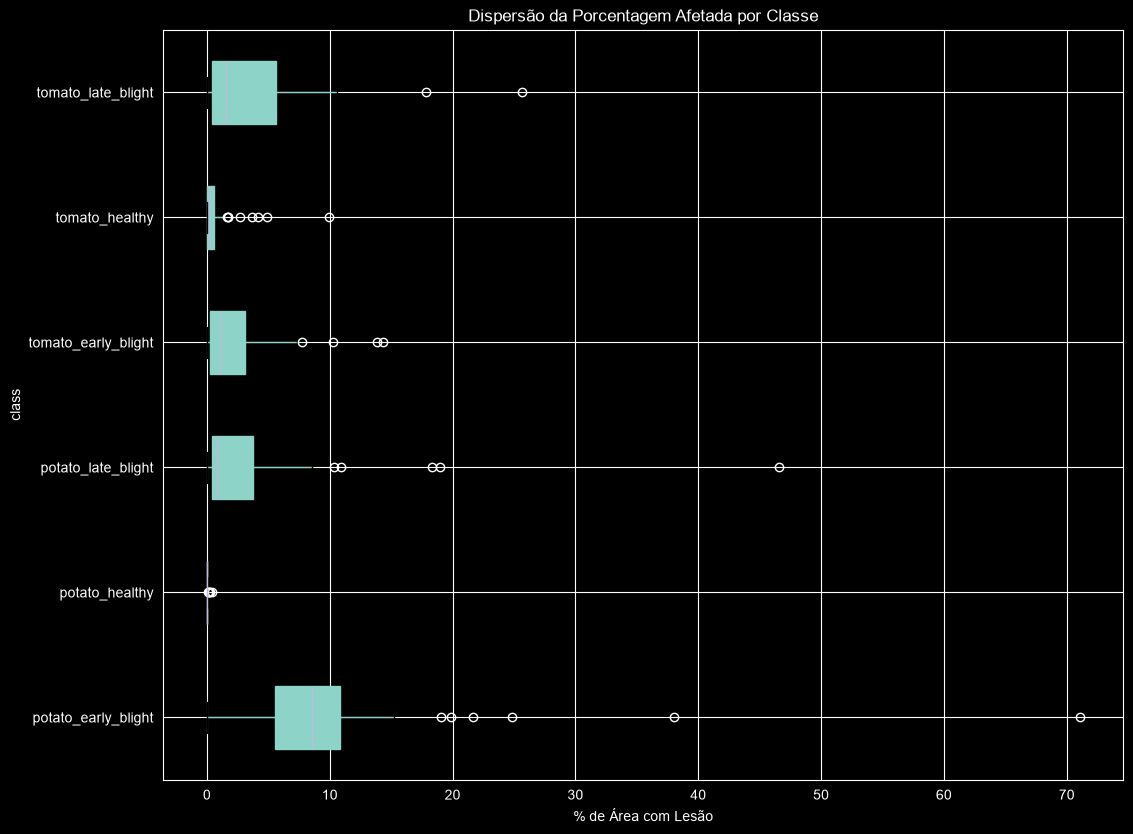

In [5]:
results_path = RESULTS_DIR / "csv_results.csv"
if results_path.exists():
    df = pd.read_csv(results_path)
    print(f"Total de imagens analisadas: {len(df)}")
    
    # Agregação por categoria e severidade detectada
    resumo = df.groupby(['class', 'severity']).size().unstack(fill_value=0)
    print("\nDistribuição de Severidade por Classe Real:")
    display(resumo)
    
    # Médias de área afetada
    medias = df.groupby('class')['pct'].mean().round(2)
    print("\nPorcentagem Média de Área Afetada por Classe:")
    print(medias)
    
    # Plot da distribuição
    df.boxplot(column='pct', by='class', vert=False, patch_artist=True)
    plt.title('Dispersão da Porcentagem Afetada por Classe')
    plt.xlabel('% de Área com Lesão')
    plt.suptitle('') 
    plt.show()
else:
    print(f"ERRO: Arquivo {results_path} não encontrado.")


### 2.2 Demonstração com Exemplos Reais
Executamos o pipeline em tempo real sobre amostras representativas do dataset.


--- Batata Saudável ---
Processando: 0be9d721-82f5-42c3-b535-7494afe01dbe___RS_HL 1814.JPG (potato_healthy)


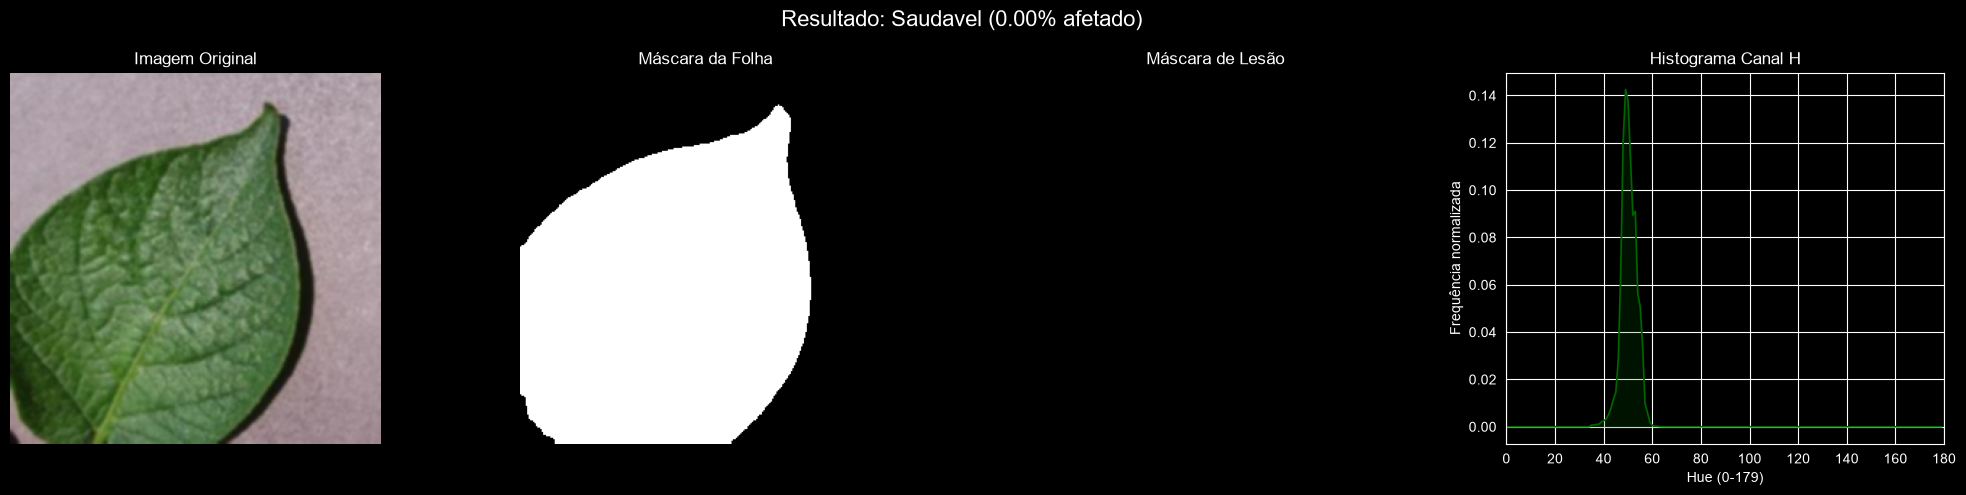


--- Batata com Early Blight (Pinta Preta) ---
Processando: 1f80f111-6a3e-4dfc-8456-0f3e9a19ae10___RS_Early.B 6879.JPG (potato_early_blight)


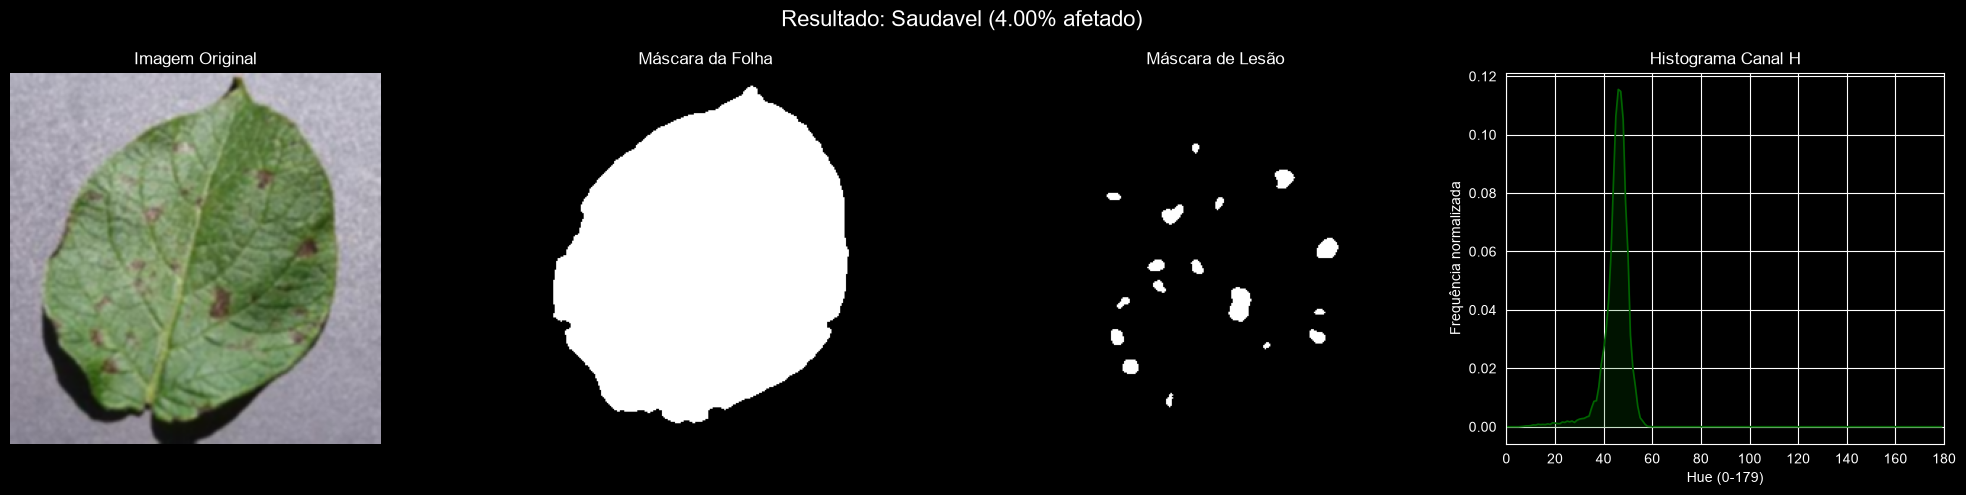


--- Tomate com Late Blight (Requeima) ---
Processando: 021a9808-21f7-464a-8df2-2eda5ed98eda___RS_Late.B 5356.JPG (tomato_late_blight)


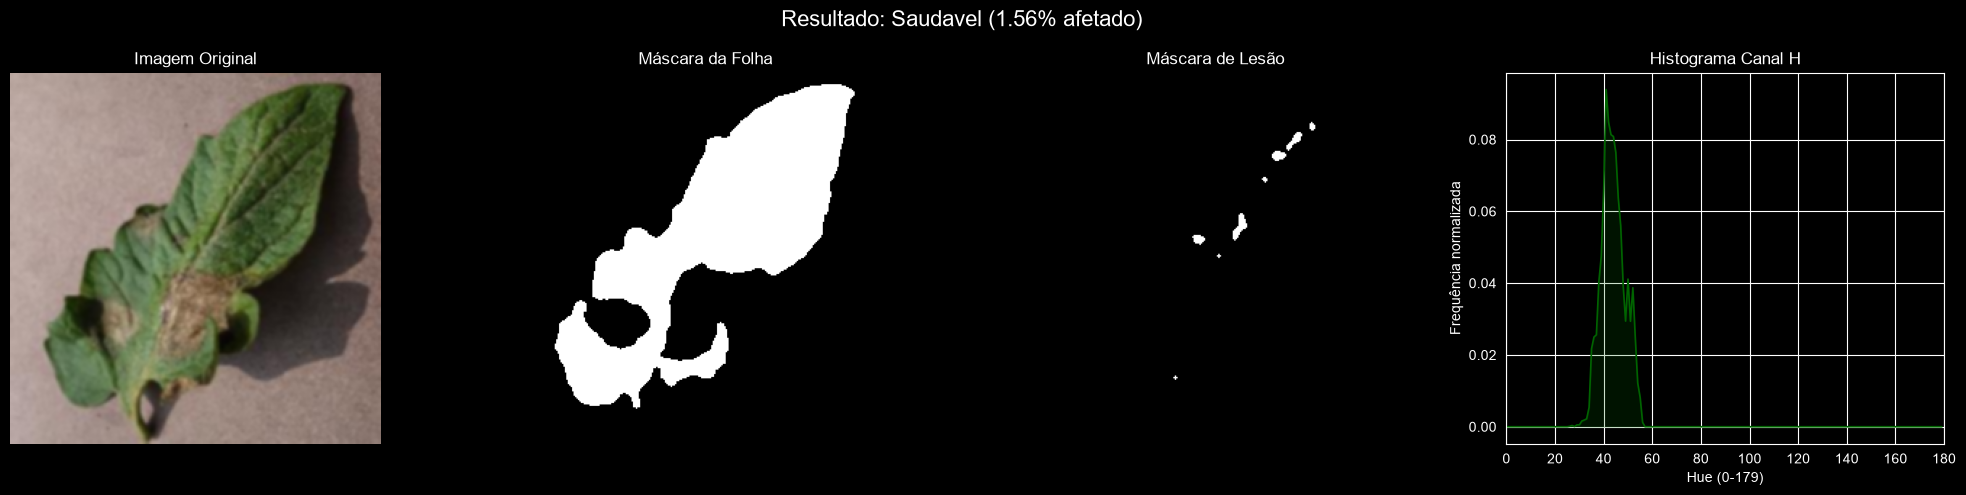


--- Tomate Saudável ---
Processando: 014b5e19-7917-4d76-b632-b5dd31d999ec___RS_HL 9640.JPG (tomato_healthy)


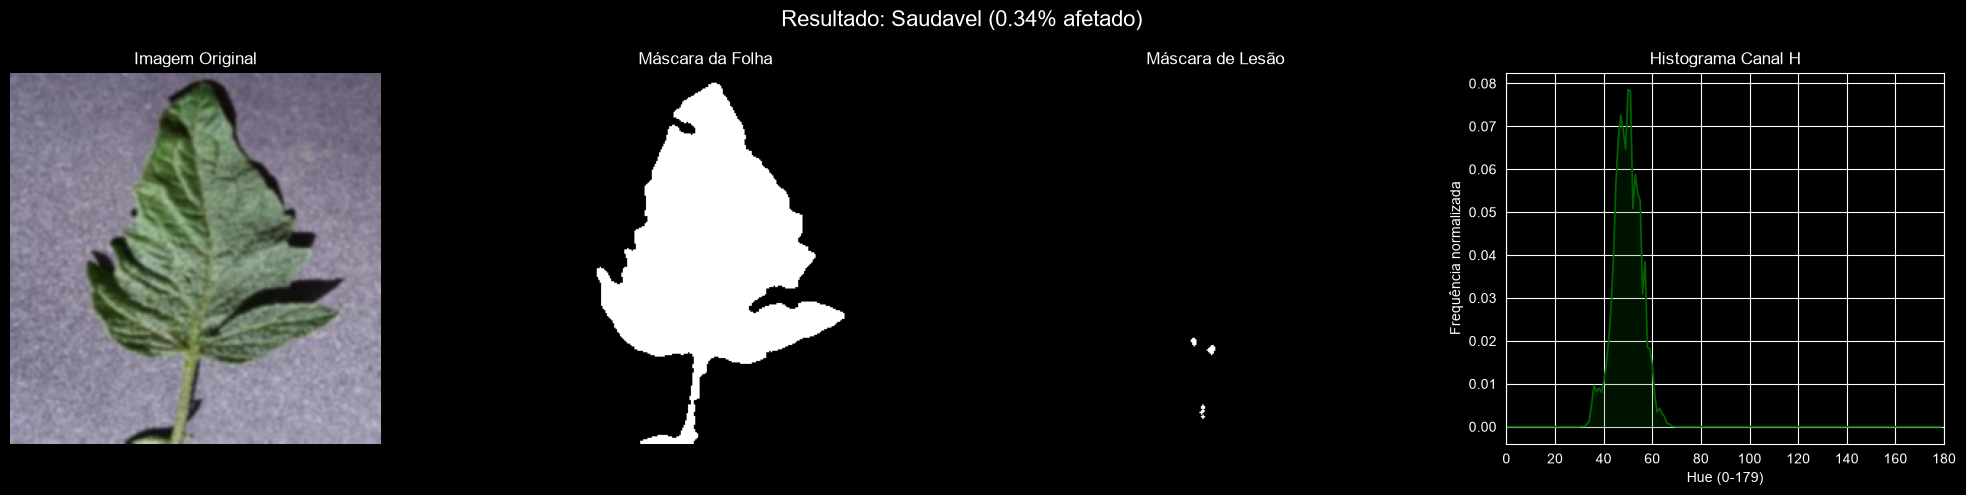

In [6]:
def mostrar_resultado_real(categoria, index=0):
    img_list = sorted([f for f in os.listdir(SELECTED_DATA_DIR / categoria) if f.endswith('.JPG')])
    if not img_list:
        print(f"Sem imagens em {categoria}")
        return
    
    img_name = img_list[min(index, len(img_list)-1)]
    img_path = SELECTED_DATA_DIR / categoria / img_name
    
    print(f"Processando: {img_name} ({categoria})")
    res = process_image(str(img_path), config=PipelineConfig(gerar_painel=True))
    
    if res['panel']:
        res['panel'].suptitle(f"Resultado: {res['severity']} ({res['pct_affected']:.2f}% afetado)", fontsize=16)
        plt.show()

# Exemplos variados
print("--- Batata Saudável ---")
mostrar_resultado_real('potato_healthy', 0)

print("\n--- Batata com Early Blight (Pinta Preta) ---")
mostrar_resultado_real('potato_early_blight', 5)

print("\n--- Tomate com Late Blight (Requeima) ---")
mostrar_resultado_real('tomato_late_blight', 2)

print("\n--- Tomate Saudável ---")
mostrar_resultado_real('tomato_healthy', 1)


## 3. Discussão e Limitações (F6.3)

### 3.1 Análise dos Resultados
Os dados do `csv_results.csv` mostram que o sistema é altamente eficaz na distinção entre folhas saudáveis e doentes. A maioria das imagens na categoria `healthy` apresenta 0% ou valores muito baixos (<0.5%) de área afetada, validando a robustez dos thresholds HSV iniciais.

### 3.2 Casos de Falha e Análise de Erros
Apesar do bom desempenho geral, foram identificados casos críticos durante a validação (F5):

- **Falso Positivo (Exemplo: `potato_early_blight` / `00d8f10f-5038-4e0f-bb58-0b885ddc0cc5___RS_Early.B 8722.JPG`)**:
  - *Observação*: Esta imagem de Early Blight foi classificada como `Saudavel` (apenas 0.05% afetado).
  - *Causa Técnica*: As lesões nesta folha específica são muito pequenas ou possuem bordas muito suaves que não atingiram a saturação mínima definida no `LesionDetectionConfig`.
  
- **Falso Positivo em Saudáveis**:
  - *Causa Técnica*: Em algumas amostras, reflexos especulares próximos à nervura central ou bordas ressecadas da folha caem dentro do range HSV de amarelo/marrom, sendo erroneamente quantificados como lesão leve.

### 3.3 Pontos Fortes
- **Critério de Intersecção**: A técnica de `intersect_with_leaf` provou ser essencial para evitar que ruídos no fundo da imagem fossem contados como doença.
- **Velocidade**: O pipeline clássico processa imagens em frações de segundo, permitindo triagem em tempo real.
- **Simplicidade**: O uso de HSV em vez de Deep Learning torna o sistema interpretável — sabemos exatamente por que um pixel foi classificado como lesão.

### 3.4 Limitações e Melhorias
- **Iluminação**: O maior gargalo é a dependência de ranges HSV fixos. Mudanças na temperatura de cor da fonte de luz deslocam os valores de Matiz (H), podendo causar falhas massivas.
- **Generalização**: O sistema atual exige calibração manual para novas espécies.
- **Sugestão de Evolução**: Implementar uma etapa de normalização de cor (como o algoritmo Gray World) ou utilizar aprendizado supervisionado (Random Forest ou SVM) sobre as características extraídas pelo OpenCV para uma classificação de severidade mais refinada.

## 4. Conclusão

O projeto atingiu os objetivos de automatizar a quantificação de doenças foliares. O pipeline desenvolvido oferece uma métrica objetiva (% de área afetada) que elimina a subjetividade da avaliação visual humana, fornecendo uma ferramenta valiosa para o monitoramento agrícola.
